Author: Author: Phan Thuy Tien

Student ID: 24280043 (VNU-HCM University of Science)

## 1. Data Cleaning & Quality Control

In [1]:
import pandas as pd
import numpy as np

### 1.1 Data preprocessing: Orders



In [4]:
df_orders_Q1 = pd.read_csv('lab03_Orders_Q1.csv')
df_orders_Q1

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,""""""
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,""""""
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,HC-2011-104759,2024-03-32,Medium,DD-13570,Thiết bị điện tử,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,TEC-AC-10004901,79.984,2.0,39.992,0.2,13.9972,NaN
277,HC-2011-101770,3/31/24,Low,KB-16240,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001097,1.869,1.0,1.869,0.7,-1.3083,NaN
278,ĐT-2011-130428,3/31/24,High,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-CH-10002965,1125.488,7.0,160.784,0.2,98.4802,NaN
279,ĐT-2011-130428,3/31/24,Low,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,OFF-BI-10001636,12.645,5.0,2.529,0.7,-10.1160,NaN


In [5]:
df_orders_Q1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         281 non-null    object 
 1   Order_Date       281 non-null    object 
 2   Order_Priority   281 non-null    object 
 3   Customer_ID      281 non-null    object 
 4   Industry_name    281 non-null    object 
 5   Province         279 non-null    object 
 6   Region           279 non-null    object 
 7   Channel          279 non-null    object 
 8   Product_ID       279 non-null    object 
 9   Sales            279 non-null    float64
 10  Quantity         279 non-null    float64
 11  Unit_Price       275 non-null    float64
 12  Discount         259 non-null    float64
 13  Profit           279 non-null    float64
 14  Returned_Reason  10 non-null     object 
dtypes: float64(5), object(10)
memory usage: 33.1+ KB


In [6]:
df_orders_Q1.describe()

,Sales,Quantity,Unit_Price,Discount,Profit
count,279.000000,279.000000,275.000000,259.00000,279.000000
mean,259.259140,3.598566,63.532332,0.16834,13.606979
std,1396.965947,2.214276,238.509409,0.22016,154.799742
min,-391.980000,-4.000000,0.360000,-0.10000,-1811.078400
25%,15.060000,2.000000,5.052000,0.00000,1.533600
50%,40.080000,3.000000,10.797000,0.20000,6.590400
75%,150.575000,5.000000,59.649500,0.20000,22.200000
max,22638.480000,14.000000,3773.080000,0.80000,909.981800


In [7]:
df_orders_Q1.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Unit_Price', 'Discount', 'Profit', 'Returned_Reason'],
      dtype='object')

In [8]:
df_orders_Q1.isnull().sum()

Order_ID             0
Order_Date           0
Order_Priority       0
Customer_ID          0
Industry_name        0
Province             2
Region               2
Channel              2
Product_ID           2
Sales                2
Quantity             2
Unit_Price           6
Discount            22
Profit               2
Returned_Reason    271
dtype: int64

In [9]:
# Check these columns: 
# Missing data: 'Province', 'Region', 'Channel', 'Product_ID', 'Sales', 'Quantity', 'Unit_Price', 'Discount', 'Profit', 'Returned_Reason'
# Invalid data in 'Sales', 'Quantity', 'Discount'
# Coloumn 'OrderDate' is not in correct format, string but not datetime

In [10]:
df_orders_Q1[df_orders_Q1.isna().any(axis = 1)]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN
5,ĐN-2011-130813,1/7/24,Medium,LS-17230,Thiết bị gia dụng,Đồng Nai,Miền Đông Nam Bộ,Store,OFF-PA-10002005,19.440,3.0,6.480,0.0,9.3312,NaN
6,HC-2011-106054,1/7/24,Medium,JO-15145,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Online,OFF-AR-10002399,12.780,3.0,4.260,NaN,5.2398,NaN
7,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị gia dụng,Hà Nội,Miền Bắc,Online,FUR-CH-10004063,2573.820,9.0,285.980,NaN,746.4078,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,HC-2011-104759,2024-03-32,Medium,DD-13570,Thiết bị điện tử,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,TEC-AC-10004901,79.984,2.0,39.992,0.2,13.9972,NaN
277,HC-2011-101770,3/31/24,Low,KB-16240,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001097,1.869,1.0,1.869,0.7,-1.3083,NaN
278,ĐT-2011-130428,3/31/24,High,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-CH-10002965,1125.488,7.0,160.784,0.2,98.4802,NaN
279,ĐT-2011-130428,3/31/24,Low,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,OFF-BI-10001636,12.645,5.0,2.529,0.7,-10.1160,NaN


In [11]:
# Make a copy of df_orders_Q1 to process data
df_Q1_copy = df_orders_Q1.copy()

# 1. Completeness

In [12]:
# Check column 'Returned_Reason'
df_Q1_copy['Returned_Reason'].unique()

array(['No reason', '""', nan, 'Damaged', 'Wrong item'], dtype=object)

In [13]:
# Replace and fill nan 
# df_Q1_copy['Returned_Reason'] = df_Q1_copy['Returned_Reason'].fillna("No return")
df_Q1_copy['Returned_Reason'] = df_Q1_copy['Returned_Reason'].replace('""', "No reason")

In [14]:
# The remained NaN value rows after altering 'Returned_Reason'
df_Q1_copy[df_Q1_copy.isna().any(axis = 1)]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN
5,ĐN-2011-130813,1/7/24,Medium,LS-17230,Thiết bị gia dụng,Đồng Nai,Miền Đông Nam Bộ,Store,OFF-PA-10002005,19.440,3.0,6.480,0.0,9.3312,NaN
6,HC-2011-106054,1/7/24,Medium,JO-15145,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Online,OFF-AR-10002399,12.780,3.0,4.260,NaN,5.2398,NaN
7,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị gia dụng,Hà Nội,Miền Bắc,Online,FUR-CH-10004063,2573.820,9.0,285.980,NaN,746.4078,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,HC-2011-104759,2024-03-32,Medium,DD-13570,Thiết bị điện tử,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,TEC-AC-10004901,79.984,2.0,39.992,0.2,13.9972,NaN
277,HC-2011-101770,3/31/24,Low,KB-16240,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001097,1.869,1.0,1.869,0.7,-1.3083,NaN
278,ĐT-2011-130428,3/31/24,High,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-CH-10002965,1125.488,7.0,160.784,0.2,98.4802,NaN
279,ĐT-2011-130428,3/31/24,Low,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,OFF-BI-10001636,12.645,5.0,2.529,0.7,-10.1160,NaN


In [15]:
# Check columns 'Sales'
df_Q1_copy[df_Q1_copy['Sales'].isna()]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
146,ĐN-2011-105648,3/3/24,Low,EJ-14155,Thiết bị gia dụng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
164,HC-2011-140116,3/10/24,Medium,KT-16480,Thiết bị gia dụng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Review again before dropping
df_Q1_copy[df_Q1_copy['Order_ID'].isin(['ĐN-2011-105648', 'HC-2011-140116'])]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
146,ĐN-2011-105648,3/3/24,Low,EJ-14155,Thiết bị gia dụng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
163,HC-2011-140116,3/10/24,Low,KT-16480,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-ST-10000078,636.408,3.0,212.136,0.2,-15.9102,NaN
164,HC-2011-140116,3/10/24,Medium,KT-16480,Thiết bị gia dụng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Add condition to make sure
df_Q1_copy[(df_Q1_copy['Order_ID'].isin(['ĐN-2011-105648', 'HC-2011-140116']) & df_Q1_copy['Sales'].isna())]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
146,ĐN-2011-105648,3/3/24,Low,EJ-14155,Thiết bị gia dụng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
164,HC-2011-140116,3/10/24,Medium,KT-16480,Thiết bị gia dụng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Dropping
df_Q1_copy = df_Q1_copy.drop(df_Q1_copy[(df_Q1_copy['Order_ID'].isin(['ĐN-2011-105648', 'HC-2011-140116']) & df_Q1_copy['Sales'].isna())].index)

In [19]:
# Check dataset again
df_Q1_copy.isna().sum()

Order_ID             0
Order_Date           0
Order_Priority       0
Customer_ID          0
Industry_name        0
Province             0
Region               0
Channel              0
Product_ID           0
Sales                0
Quantity             0
Unit_Price           4
Discount            20
Profit               0
Returned_Reason    269
dtype: int64

In [20]:
# Check unit_price
df_Q1_copy[df_Q1_copy['Unit_Price'].isna()]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.54,2.0,NaN,0.8,-5.4870,NaN
26,ĐT-2011-109232,1/14/24,High,ND-18370,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-CH-10000422,545.94,6.0,NaN,NaN,87.3504,NaN
57,ĐT-2011-167927,1/21/24,Medium,XP-21865,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-FU-10002268,14.73,3.0,NaN,0.0,4.8609,NaN
87,HN-2011-131905,2/7/24,Medium,ND-18460,Thiết bị gia dụng,Hà Nội,Miền Bắc,Agent,OFF-LA-10002787,15.00,4.0,NaN,0.0,7.2000,NaN


In [21]:
# Fill unit_price = sales/quantity
df_Q1_copy['Unit_Price'] = df_Q1_copy['Unit_Price'].fillna(df_Q1_copy['Sales']/df_Q1_copy['Quantity'])

In [22]:
# Check discount
df_Q1_copy[df_Q1_copy['Discount'].isna()]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
6,HC-2011-106054,1/7/24,Medium,JO-15145,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Online,OFF-AR-10002399,12.78,3.0,4.26,NaN,5.2398,NaN
7,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị gia dụng,Hà Nội,Miền Bắc,Online,FUR-CH-10004063,2573.82,9.0,285.98,NaN,746.4078,NaN
8,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị gia dụng,Hà Nội,Miền Bắc,Online,OFF-BI-10004632,609.98,2.0,304.99,NaN,274.4910,NaN
9,HN-2011-167199,1/7/24,Medium,ME-17320,Thiết bị gia dụng,Hà Nội,Miền Bắc,Online,OFF-AR-10001662,5.48,2.0,2.74,NaN,1.4796,NaN
10,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị điện tử,Hà Nội,Miền Bắc,Online,TEC-PH-10004977,-391.98,2.0,195.99,NaN,113.6742,NaN
11,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị điện tử,Hà Nội,Miền Bắc,Online,TEC-PH-10004539,755.96,4.0,188.99,NaN,204.1092,NaN
12,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị gia dụng,Hà Nội,Miền Bắc,Online,OFF-FA-10001883,31.12,4.0,7.78,NaN,0.3112,NaN
13,HN-2011-167199,1/7/24,Medium,ME-17320,Thiết bị gia dụng,Hà Nội,Miền Bắc,Online,OFF-PA-10000955,6.54,1.0,6.54,NaN,3.0084,Damaged
18,HG-2011-149020,1/11/24,Medium,AJ-10780,Thiết bị gia dụng,Hà Giang,Miền Bắc,Store,OFF-LA-10004272,2.89,1.0,2.89,NaN,1.3583,NaN
19,HG-2011-149020,1/11/24,Medium,AJ-10780,Thiết bị gia dụng,Hà Giang,Miền Bắc,Store,FUR-FU-10000965,51.94,1.0,51.94,NaN,21.2954,NaN


In [23]:
df_Q1_copy['Discount'] = df_Q1_copy['Discount'].fillna(0)

In [24]:
# The remained NaN value rows after all
df_Q1_copy[df_Q1_copy.isna().any(axis = 1)]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,1.770,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN
5,ĐN-2011-130813,1/7/24,Medium,LS-17230,Thiết bị gia dụng,Đồng Nai,Miền Đông Nam Bộ,Store,OFF-PA-10002005,19.440,3.0,6.480,0.0,9.3312,NaN
6,HC-2011-106054,1/7/24,Medium,JO-15145,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Online,OFF-AR-10002399,12.780,3.0,4.260,0.0,5.2398,NaN
7,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị gia dụng,Hà Nội,Miền Bắc,Online,FUR-CH-10004063,2573.820,9.0,285.980,0.0,746.4078,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,HC-2011-104759,2024-03-32,Medium,DD-13570,Thiết bị điện tử,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,TEC-AC-10004901,79.984,2.0,39.992,0.2,13.9972,NaN
277,HC-2011-101770,3/31/24,Low,KB-16240,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001097,1.869,1.0,1.869,0.7,-1.3083,NaN
278,ĐT-2011-130428,3/31/24,High,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-CH-10002965,1125.488,7.0,160.784,0.2,98.4802,NaN
279,ĐT-2011-130428,3/31/24,Low,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,OFF-BI-10001636,12.645,5.0,2.529,0.7,-10.1160,NaN


# 2. Accuracy

In [25]:
# Check invalid data in 'Sales', 'Quantity', 'Discount'
df_Q1_copy[(df_Q1_copy[['Sales','Quantity','Discount']] < 0).any(axis = 1)]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
10,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị điện tử,Hà Nội,Miền Bắc,Online,TEC-PH-10004977,-391.98,2.0,195.99,0.00,113.6742,NaN
93,HN-2011-125759,2/9/24,Medium,NM-18445,Thiết bị gia dụng,Hà Nội,Miền Bắc,Store,FUR-FU-10002111,-14.56,2.0,7.28,0.00,5.5328,NaN
105,QN-2011-121762,2/15/24,High,ML-17395,Thiết bị điện tử,Quảng Ninh,Miền Bắc,Store,TEC-AC-10000736,139.97,-3.0,79.99,-0.10,86.3892,NaN
135,HC-2011-107524,3/2/24,Medium,KN-16705,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-PA-10000587,36.40,5.0,7.28,-0.05,17.4720,NaN
193,HC-2011-118339,3/17/24,Medium,BN-11515,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001758,53.40,10.0,5.34,-0.05,25.0980,NaN
199,TN-2011-148838,3/17/24,High,CP-12340,Thiết bị gia dụng,Thái Nguyên,Miền Bắc,Agent,OFF-PA-10000919,155.04,-4.0,38.76,0.00,75.9696,NaN


In [26]:
# Replace by absolute value 
df_Q1_copy[['Sales','Quantity','Discount']] = df_Q1_copy[['Sales','Quantity','Discount']].abs()

In [27]:
# Review
df_Q1_copy[(df_Q1_copy[['Sales','Quantity','Discount']] < 0).any(axis = 1)]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason


# 3. Validity

In [28]:
# 3.1 Identify categorical columns with 20 or fewer unique values.
categorical_cols = [col for col in df_Q1_copy.select_dtypes(include=['object']).columns if df_Q1_copy[col].nunique() <= 20]
print("Identify categorical columns with 20 or fewer unique valuesc:", categorical_cols)

Identify categorical columns with 20 or fewer unique valuesc: ['Order_Priority', 'Industry_name', 'Region', 'Channel', 'Returned_Reason']


In [29]:
# 3.2 Inspect the data in each column to identify errors.
for col in categorical_cols:
    print(f"🔹 Column: {col}")
    print(df_Q1_copy[col].value_counts(dropna=False)) 
    print("-" * 50)

🔹 Column: Order_Priority
Order_Priority
Medium    182
Low        56
High       41
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Industry_name
Industry_name
Thiết bị gia dụng    240
Thiết bị điện tử      39
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Region
Region
Miền Đông Nam Bộ    115
Miền Trung           70
Miền Bắc             59
Miền Tây Nam Bộ      33
'                     1
Hà Nội                1
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Channel
Channel
Store             101
Agent              92
Online             65
agent              14
online channel      7
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Returned_Reason
Returned_Reason
NaN           269
No reason       5
Wrong item      3
Damaged         2
Name: count, dtype: int64
--------------------------------------------------


In [30]:
# Handle columns: Region, Channel
# Region
df_Q1_copy[df_Q1_copy['Region'] == "'"]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
183,VP-2011-100293,3/14/24,Medium,NF-18475,Thiết bị gia dụng,Vĩnh Phúc,',Agent,OFF-PA-10000176,91.056,6.0,15.176,0.2,31.8696,NaN


In [31]:
# Standardize data
df_Q1_copy.loc[df_Q1_copy['Province'] == 'Vĩnh Phúc', 'Region'] = 'Miền Bắc'
df_Q1_copy['Region'] = df_Q1_copy['Region'].replace('Hà Nội','Miền Bắc')

In [32]:
# Double check
for col in categorical_cols:
    print(f"Column {col} after handling Region:")
    print(df_Q1_copy[col].value_counts())
    print("-" * 50)

Column Order_Priority after handling Region:
Order_Priority
Medium    182
Low        56
High       41
Name: count, dtype: int64
--------------------------------------------------
Column Industry_name after handling Region:
Industry_name
Thiết bị gia dụng    240
Thiết bị điện tử      39
Name: count, dtype: int64
--------------------------------------------------
Column Region after handling Region:
Region
Miền Đông Nam Bộ    115
Miền Trung           70
Miền Bắc             61
Miền Tây Nam Bộ      33
Name: count, dtype: int64
--------------------------------------------------
Column Channel after handling Region:
Channel
Store             101
Agent              92
Online             65
agent              14
online channel      7
Name: count, dtype: int64
--------------------------------------------------
Column Returned_Reason after handling Region:
Returned_Reason
No reason     5
Wrong item    3
Damaged       2
Name: count, dtype: int64
--------------------------------------------------

In [33]:
# Channel
df_Q1_copy['Channel'] = df_Q1_copy['Channel'].replace({'agent': 'Agent', 'online channel': 'Online'})

In [34]:
# Double check
for col in categorical_cols:
    print(f"Column {col} after handling Channel:")
    print(df_Q1_copy[col].value_counts())
    print("-" * 50)

Column Order_Priority after handling Channel:
Order_Priority
Medium    182
Low        56
High       41
Name: count, dtype: int64
--------------------------------------------------
Column Industry_name after handling Channel:
Industry_name
Thiết bị gia dụng    240
Thiết bị điện tử      39
Name: count, dtype: int64
--------------------------------------------------
Column Region after handling Channel:
Region
Miền Đông Nam Bộ    115
Miền Trung           70
Miền Bắc             61
Miền Tây Nam Bộ      33
Name: count, dtype: int64
--------------------------------------------------
Column Channel after handling Channel:
Channel
Agent     106
Store     101
Online     72
Name: count, dtype: int64
--------------------------------------------------
Column Returned_Reason after handling Channel:
Returned_Reason
No reason     5
Wrong item    3
Damaged       2
Name: count, dtype: int64
--------------------------------------------------


# 4. Timeless

In [35]:
# Create new column and convert Order_Date type to datetime, if error -> NaT
df_Q1_copy['order_date_original'] = df_Q1_copy['Order_Date']
df_Q1_copy['order_date_cleaned'] = df_Q1_copy['Order_Date']
df_Q1_copy['Order_Date'] = pd.to_datetime(df_Q1_copy['Order_Date'], errors='coerce')

C:\Users\Admin\AppData\Local\Temp\ipykernel_21484\3057222554.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_Q1_copy['Order_Date'] = pd.to_datetime(df_Q1_copy['Order_Date'], errors='coerce')


In [36]:
df_Q1_copy

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,order_date_original,order_date_cleaned
0,HC-2011-103800,2024-01-04,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,1/4/24,1/4/24
1,NA-2011-112326,2024-01-05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,No reason,2024.01.05,2024.01.05
2,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,No reason,1/5/24,1/5/24
3,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,1.770,0.8,-5.4870,NaN,1/5/24,1/5/24
4,TN-2011-141817,2024-01-06,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,1/6/24,1/6/24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,HC-2011-104759,NaT,Medium,DD-13570,Thiết bị điện tử,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,TEC-AC-10004901,79.984,2.0,39.992,0.2,13.9972,NaN,2024-03-32,2024-03-32
277,HC-2011-101770,2024-03-31,Low,KB-16240,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001097,1.869,1.0,1.869,0.7,-1.3083,NaN,3/31/24,3/31/24
278,ĐT-2011-130428,2024-03-31,High,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-CH-10002965,1125.488,7.0,160.784,0.2,98.4802,NaN,3/31/24,3/31/24
279,ĐT-2011-130428,2024-03-31,Low,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,OFF-BI-10001636,12.645,5.0,2.529,0.7,-10.1160,NaN,3/31/24,3/31/24


In [37]:
df_Q1_copy[df_Q1_copy['Order_Date'].isna()][['order_date_original']]

,order_date_original
275,2024-03-32
276,2024-03-32


In [38]:
df_Q1_copy['order_date_cleaned'] = df_Q1_copy['order_date_cleaned'].astype(str)
df_Q1_copy['order_date_cleaned'] = df_Q1_copy['order_date_cleaned'].str.replace(r"[./]", "-", regex=True)
df_Q1_copy['order_date_cleaned'] = df_Q1_copy['order_date_cleaned'].replace("2024-03-32", "2024-03-31")
df_Q1_copy['order_date_cleaned'] = pd.to_datetime(df_Q1_copy['order_date_cleaned'], format="mixed", dayfirst=True).dt.strftime('%Y-%m-%d')

In [39]:
df_Q1_copy

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,order_date_original,order_date_cleaned
0,HC-2011-103800,2024-01-04,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,1/4/24,2024-04-01
1,NA-2011-112326,2024-01-05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,No reason,2024.01.05,2024-01-05
2,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,No reason,1/5/24,2024-05-01
3,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,1.770,0.8,-5.4870,NaN,1/5/24,2024-05-01
4,TN-2011-141817,2024-01-06,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,1/6/24,2024-06-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,HC-2011-104759,NaT,Medium,DD-13570,Thiết bị điện tử,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,TEC-AC-10004901,79.984,2.0,39.992,0.2,13.9972,NaN,2024-03-32,2024-03-31
277,HC-2011-101770,2024-03-31,Low,KB-16240,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001097,1.869,1.0,1.869,0.7,-1.3083,NaN,3/31/24,2024-03-31
278,ĐT-2011-130428,2024-03-31,High,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-CH-10002965,1125.488,7.0,160.784,0.2,98.4802,NaN,3/31/24,2024-03-31
279,ĐT-2011-130428,2024-03-31,Low,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,OFF-BI-10001636,12.645,5.0,2.529,0.7,-10.1160,NaN,3/31/24,2024-03-31


In [40]:
df_Q1_copy[df_Q1_copy['Order_Date'].isna()][['order_date_cleaned']]
df_Q1_copy['Order_Date'].fillna(df_Q1_copy['order_date_cleaned'], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21484\3754830708.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_Q1_copy['Order_Date'].fillna(df_Q1_copy['order_date_cleaned'], inplace=True)


In [41]:
df_Q1_copy[df_Q1_copy['Order_Date'].isna()][['order_date_original']]

,order_date_original


In [42]:
df_Q1_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279 entries, 0 to 280
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_ID             279 non-null    object        
 1   Order_Date           279 non-null    datetime64[ns]
 2   Order_Priority       279 non-null    object        
 3   Customer_ID          279 non-null    object        
 4   Industry_name        279 non-null    object        
 5   Province             279 non-null    object        
 6   Region               279 non-null    object        
 7   Channel              279 non-null    object        
 8   Product_ID           279 non-null    object        
 9   Sales                279 non-null    float64       
 10  Quantity             279 non-null    float64       
 11  Unit_Price           279 non-null    float64       
 12  Discount             279 non-null    float64       
 13  Profit               279 non-null    flo

# 5. Uniqueness

In [43]:
# Check duplicates
df_Q1_copy.duplicated().sum()

np.int64(0)

In [44]:
df_Q1_copy = df_Q1_copy.drop(columns=['order_date_original', 'order_date_cleaned'])

In [45]:
df_Q1_copy

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,HC-2011-103800,2024-01-04,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason
1,NA-2011-112326,2024-01-05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,No reason
2,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,No reason
3,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,1.770,0.8,-5.4870,NaN
4,TN-2011-141817,2024-01-06,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,HC-2011-104759,2024-03-31,Medium,DD-13570,Thiết bị điện tử,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,TEC-AC-10004901,79.984,2.0,39.992,0.2,13.9972,NaN
277,HC-2011-101770,2024-03-31,Low,KB-16240,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001097,1.869,1.0,1.869,0.7,-1.3083,NaN
278,ĐT-2011-130428,2024-03-31,High,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,FUR-CH-10002965,1125.488,7.0,160.784,0.2,98.4802,NaN
279,ĐT-2011-130428,2024-03-31,Low,TG-21640,Thiết bị gia dụng,Đồng Tháp,Miền Tây Nam Bộ,Agent,OFF-BI-10001636,12.645,5.0,2.529,0.7,-10.1160,NaN


In [46]:
df_orders_Q2 = pd.read_csv('lab03_Orders_Q2.csv')

In [47]:
df_orders_Q2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         222 non-null    object 
 1   Order_Date       222 non-null    object 
 2   Order_Priority   221 non-null    object 
 3   Customer_ID      221 non-null    object 
 4   Industry_name    221 non-null    object 
 5   Province         221 non-null    object 
 6   Region           219 non-null    object 
 7   Channel          221 non-null    object 
 8   Product_ID       221 non-null    object 
 9   Sales            221 non-null    float64
 10  Quantity         221 non-null    float64
 11  Price            221 non-null    float64
 12  Discount         221 non-null    float64
 13  Profit           221 non-null    float64
 14  Returned_Reason  0 non-null      float64
 15  Notes            0 non-null      float64
dtypes: float64(7), object(9)
memory usage: 27.9+ KB


In [48]:
df_orders_Q2.describe()

,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes
count,221.000000,221.000000,221.000000,221.000000,221.000000,0.0,0.0
mean,202.710964,3.963801,51.612656,0.127376,23.898132,NaN,NaN
std,435.134846,2.358457,90.555068,0.172638,111.205438,NaN,NaN
min,2.368000,1.000000,0.834000,0.000000,-407.976000,NaN,NaN
25%,18.288000,2.000000,5.470000,0.000000,2.777600,NaN,NaN
50%,55.480000,3.000000,15.930000,0.000000,9.072000,NaN,NaN
75%,177.680000,5.000000,53.480000,0.200000,26.703000,NaN,NaN
max,4164.050000,14.000000,832.810000,0.800000,1276.487100,NaN,NaN


In [49]:
df_orders_Q2.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Price', 'Discount', 'Profit', 'Returned_Reason', 'Notes'],
      dtype='object')

In [50]:
# Check columns: 'Order_Priority', 'Customer_ID', 'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
# 'Quantity', 'Price', 'Discount', 'Profit', 'Returned_Reason', 'Notes'


In [51]:
# Make a copy of df_orders_Q2 to process data
df_Q2_copy = df_orders_Q2.copy()

# 1. Completeness

In [52]:
df_Q2_copy.isna().sum()

Order_ID             0
Order_Date           0
Order_Priority       1
Customer_ID          1
Industry_name        1
Province             1
Region               3
Channel              1
Product_ID           1
Sales                1
Quantity             1
Price                1
Discount             1
Profit               1
Returned_Reason    222
Notes              222
dtype: int64

In [53]:
# Check NaN rows
except_col = ['Returned_Reason', 'Notes']
tmp = df_Q2_copy.drop(columns = except_col).isna().any(axis = 1)
nan_rows = df_Q2_copy[tmp]
nan_rows

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes
212,VP-2011-152443,5/21/24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,VP-2011-152443,5/21/24,Medium,FG-14260,Thiết bị gia dụng,Vĩnh Phúc,NaN,Agent,OFF-PA-10003022,17.940,3.0,5.980,0.0,8.7906,NaN,NaN
216,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,NaN,Agent,FUR-CH-10003396,107.772,2.0,53.886,0.3,-29.2524,NaN,NaN


In [54]:
# Check Customer_ID
df_Q2_copy[df_Q2_copy['Customer_ID'].isna()]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes
212,VP-2011-152443,5/21/24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
# Dropping row
df_Q2_copy = df_Q2_copy.drop(df_Q2_copy[df_Q2_copy['Customer_ID'].isna()].index)

In [56]:
# Review 
df_Q2_copy.isna().sum()

Order_ID             0
Order_Date           0
Order_Priority       0
Customer_ID          0
Industry_name        0
Province             0
Region               2
Channel              0
Product_ID           0
Sales                0
Quantity             0
Price                0
Discount             0
Profit               0
Returned_Reason    221
Notes              221
dtype: int64

In [57]:
# Check region
nan_rows.drop(nan_rows[nan_rows['Customer_ID'].isna()].index)

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes
213,VP-2011-152443,5/21/24,Medium,FG-14260,Thiết bị gia dụng,Vĩnh Phúc,NaN,Agent,OFF-PA-10003022,17.940,3.0,5.980,0.0,8.7906,NaN,NaN
216,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,NaN,Agent,FUR-CH-10003396,107.772,2.0,53.886,0.3,-29.2524,NaN,NaN


In [58]:
# Standardize Region
df_Q2_copy.loc[df_Q2_copy['Province'] == 'Vĩnh Phúc','Region'] = 'Miền Bắc'
df_Q2_copy.loc[df_Q2_copy['Province'] == 'Hà Tỉnh','Region'] = 'Miền Trung'

In [59]:
# review df_Q2_copy again
df_Q2_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 0 to 221
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         221 non-null    object 
 1   Order_Date       221 non-null    object 
 2   Order_Priority   221 non-null    object 
 3   Customer_ID      221 non-null    object 
 4   Industry_name    221 non-null    object 
 5   Province         221 non-null    object 
 6   Region           221 non-null    object 
 7   Channel          221 non-null    object 
 8   Product_ID       221 non-null    object 
 9   Sales            221 non-null    float64
 10  Quantity         221 non-null    float64
 11  Price            221 non-null    float64
 12  Discount         221 non-null    float64
 13  Profit           221 non-null    float64
 14  Returned_Reason  0 non-null      float64
 15  Notes            0 non-null      float64
dtypes: float64(7), object(9)
memory usage: 29.4+ KB


In [60]:
df_Q2_copy.isna().sum()

Order_ID             0
Order_Date           0
Order_Priority       0
Customer_ID          0
Industry_name        0
Province             0
Region               0
Channel              0
Product_ID           0
Sales                0
Quantity             0
Price                0
Discount             0
Profit               0
Returned_Reason    221
Notes              221
dtype: int64

# 2. Accuracy

In [61]:
df_Q2_copy.describe()
# Data seems good

,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes
count,221.000000,221.000000,221.000000,221.000000,221.000000,0.0,0.0
mean,202.710964,3.963801,51.612656,0.127376,23.898132,NaN,NaN
std,435.134846,2.358457,90.555068,0.172638,111.205438,NaN,NaN
min,2.368000,1.000000,0.834000,0.000000,-407.976000,NaN,NaN
25%,18.288000,2.000000,5.470000,0.000000,2.777600,NaN,NaN
50%,55.480000,3.000000,15.930000,0.000000,9.072000,NaN,NaN
75%,177.680000,5.000000,53.480000,0.200000,26.703000,NaN,NaN
max,4164.050000,14.000000,832.810000,0.800000,1276.487100,NaN,NaN


# 3. Validity

In [62]:
categorical_cols = [col for col in df_Q2_copy.select_dtypes(include=['object']).columns if df_Q2_copy[col].nunique() <= 20]
print("Identify categorical columns with 20 or fewer unique valuesc:", categorical_cols)

Identify categorical columns with 20 or fewer unique valuesc: ['Order_Priority', 'Industry_name', 'Region', 'Channel']


In [63]:
for col in categorical_cols:
    print(f"🔹 Column: {col}")
    print(df_Q2_copy[col].value_counts(dropna=False))  # Hiển thị số lần xuất hiện của từng giá trị (kể cả NaN)
    print("-" * 50)
# Need to handle columns: Region

🔹 Column: Order_Priority
Order_Priority
Medium    148
High       40
Low        33
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Industry_name
Industry_name
Thiết bị gia dụng    181
Thiết bị điện tử      40
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Region
Region
Miền Đông Nam Bộ    85
Miền Trung          81
Miền Bắc            40
Miền Tây Nam Bộ     13
""                   2
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Channel
Channel
Agent     132
Store      59
Online     30
Name: count, dtype: int64
--------------------------------------------------


In [64]:
# Region
df_Q2_copy[df_Q2_copy['Region'] == '""']

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes
192,PT-2011-106810,5/14/24,Medium,AJ-10795,Thiết bị gia dụng,Phú Thọ,"""""",Agent,FUR-FU-10004306,310.88,2.0,155.44,0.2,23.3160,NaN,NaN
202,KH-2011-114188,5/20/24,Medium,RF-19345,Thiết bị gia dụng,Khánh Hòa,"""""",Agent,OFF-AP-10000124,33.28,4.0,8.32,0.0,9.3184,NaN,NaN


In [65]:
df_Q2_copy.loc[df_Q2_copy['Province'] == 'Phú Thọ','Region'] = 'Miền Bắc'
df_Q2_copy.loc[df_Q2_copy['Province'] == 'Khánh Hòa', 'Region'] = 'Miền Trung'

In [66]:
# Review Region after altering
df_Q2_copy[df_Q2_copy['Region'] == '""']

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes


In [67]:
# Double check
for col in categorical_cols:
    print(f"Column {col} after handling:")
    print(df_Q2_copy[col].value_counts())
    print("-" * 50)

Column Order_Priority after handling:
Order_Priority
Medium    148
High       40
Low        33
Name: count, dtype: int64
--------------------------------------------------
Column Industry_name after handling:
Industry_name
Thiết bị gia dụng    181
Thiết bị điện tử      40
Name: count, dtype: int64
--------------------------------------------------
Column Region after handling:
Region
Miền Đông Nam Bộ    85
Miền Trung          82
Miền Bắc            41
Miền Tây Nam Bộ     13
Name: count, dtype: int64
--------------------------------------------------
Column Channel after handling:
Channel
Agent     132
Store      59
Online     30
Name: count, dtype: int64
--------------------------------------------------


# 4. Timeless

In [68]:
# Create new column and convert date to datetime, if error --> NaT
df_Q2_copy['order_date_original'] = df_Q2_copy['Order_Date']
df_Q2_copy['order_date_cleaned'] = df_Q2_copy['Order_Date']
df_Q2_copy['Order_Date'] = pd.to_datetime(df_Q2_copy['Order_Date'], errors='coerce')

C:\Users\Admin\AppData\Local\Temp\ipykernel_21484\748547493.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_Q2_copy['Order_Date'] = pd.to_datetime(df_Q2_copy['Order_Date'], errors='coerce')


In [69]:
df_Q2_copy[df_Q2_copy['Order_Date'].isna()][['order_date_original']]

,order_date_original


In [70]:
df_Q2_copy['order_date_cleaned'] = df_Q2_copy['order_date_cleaned'].astype(str)
df_Q2_copy['order_date_cleaned'] = df_Q2_copy['order_date_cleaned'].str.replace(r"[./]", "-", regex=True)
df_Q2_copy['order_date_cleaned'] = pd.to_datetime(df_Q2_copy['order_date_cleaned'], format="mixed", dayfirst=True).dt.strftime('%Y-%m-%d')
df_Q2_copy

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes,order_date_original,order_date_cleaned
0,ĐN-2011-107181,2024-05-12,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN,NaN,5/12/24,2024-12-05
1,TG-2011-157021,2024-04-01,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN,NaN,4/1/24,2024-01-04
2,TG-2011-157021,2024-04-01,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN,NaN,4/1/24,2024-01-04
3,TG-2011-138359,2024-04-01,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN,NaN,4/1/24,2024-01-04
4,TG-2011-138359,2024-04-01,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN,NaN,4/1/24,2024-01-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN,NaN,5/21/24,2024-05-21
218,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN,NaN,5/21/24,2024-05-21
219,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN,NaN,5/21/24,2024-05-21
220,HC-2011-130673,2024-05-20,Low,MC-17590,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-ST-10000636,66.960,5.0,13.392,0.2,-13.3920,NaN,NaN,5/20/24,2024-05-20


# 5. Uniqueness

In [71]:
# Check duplicates
df_Q2_copy.duplicated().sum()

np.int64(4)

In [72]:
df_Q2_copy[df_Q2_copy.duplicated()]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes,order_date_original,order_date_cleaned
104,HT-2011-150119,2024-04-23,Low,LB-16795,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10002965,281.372,2.0,140.686,0.3,-12.0588,NaN,NaN,4/23/24,2024-04-23
219,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN,NaN,5/21/24,2024-05-21
220,HC-2011-130673,2024-05-20,Low,MC-17590,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-ST-10000636,66.960,5.0,13.392,0.2,-13.3920,NaN,NaN,5/20/24,2024-05-20
221,HC-2011-113768,2024-05-13,Medium,AH-10030,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,FUR-CH-10002439,279.456,6.0,46.576,0.2,20.9592,NaN,NaN,5/13/24,2024-05-13


In [73]:
df_Q2_copy[df_Q2_copy['Order_ID'] == 'HT-2011-150119']

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes,order_date_original,order_date_cleaned
103,HT-2011-150119,2024-04-23,Low,LB-16795,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10002965,281.372,2.0,140.686,0.3,-12.0588,NaN,NaN,4/23/24,2024-04-23
104,HT-2011-150119,2024-04-23,Low,LB-16795,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10002965,281.372,2.0,140.686,0.3,-12.0588,NaN,NaN,4/23/24,2024-04-23
105,HT-2011-150119,2024-04-23,Low,LB-16795,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000145,7.488,8.0,0.936,0.7,-5.2416,NaN,NaN,4/23/24,2024-04-23
106,HT-2011-150119,2024-04-23,Medium,LB-16795,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-FU-10002191,22.336,4.0,5.584,0.2,7.8176,NaN,NaN,4/23/24,2024-04-23


In [74]:
# Remove all duplicate rows, keeping the first occurrence
df_Q2_copy.drop_duplicates(inplace=True)

In [75]:
# Fill 'Order_Date' with 'order_date_cleaned'
df_Q2_copy['Order_Date'] = df_Q2_copy['Order_Date'].fillna(df_Q2_copy['order_date_cleaned'])
df_Q2_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, 0 to 218
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_ID             217 non-null    object        
 1   Order_Date           217 non-null    datetime64[ns]
 2   Order_Priority       217 non-null    object        
 3   Customer_ID          217 non-null    object        
 4   Industry_name        217 non-null    object        
 5   Province             217 non-null    object        
 6   Region               217 non-null    object        
 7   Channel              217 non-null    object        
 8   Product_ID           217 non-null    object        
 9   Sales                217 non-null    float64       
 10  Quantity             217 non-null    float64       
 11  Price                217 non-null    float64       
 12  Discount             217 non-null    float64       
 13  Profit               217 non-null    flo

In [76]:
# Drop columns 'order_date_original', 'order_date_cleaned'
df_Q2_copy = df_Q2_copy.drop(columns = ['order_date_original', 'order_date_cleaned'])

In [77]:
df_Q2_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, 0 to 218
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         217 non-null    object        
 1   Order_Date       217 non-null    datetime64[ns]
 2   Order_Priority   217 non-null    object        
 3   Customer_ID      217 non-null    object        
 4   Industry_name    217 non-null    object        
 5   Province         217 non-null    object        
 6   Region           217 non-null    object        
 7   Channel          217 non-null    object        
 8   Product_ID       217 non-null    object        
 9   Sales            217 non-null    float64       
 10  Quantity         217 non-null    float64       
 11  Price            217 non-null    float64       
 12  Discount         217 non-null    float64       
 13  Profit           217 non-null    float64       
 14  Returned_Reason  0 non-null      float64       

In [78]:
# df_orders_Q1.columns
df_Q1_copy.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Unit_Price', 'Discount', 'Profit', 'Returned_Reason'],
      dtype='object')

In [79]:
# df_orders_Q2.columns
df_Q2_copy.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Price', 'Discount', 'Profit', 'Returned_Reason', 'Notes'],
      dtype='object')

**Nhận xét**: df_orders_Q1 và df_orders_Q2
- có số lượng cols khác nhau
- Có 1 số cột khác nhau
==> Xử lý:
- Đồng nhất tên các cột có cùng ý nghĩa nhưng khác tên
- Chọn ra các cols có ý nghĩa hoặc cần sử dụng

# *Note: df_orders_Q1 của em là df_Q1_copy, df_orders_Q2 của em là df_Q2_copy

In [80]:
# Rename Price to Unit_Price
# df_orders_Q2 = df_orders_Q2.rename(columns={'Price':"Unit_Price"})
df_Q2_copy = df_Q2_copy.rename(columns={'Price':"Unit_Price"})

In [81]:
# df_orders_Q2
df_Q2_copy

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Notes
0,ĐN-2011-107181,2024-05-12,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN,NaN
1,TG-2011-157021,2024-04-01,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN,NaN
2,TG-2011-157021,2024-04-01,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN,NaN
3,TG-2011-138359,2024-04-01,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN,NaN
4,TG-2011-138359,2024-04-01,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,VP-2011-152443,2024-05-21,High,FG-14260,Thiết bị gia dụng,Vĩnh Phúc,Miền Bắc,Agent,OFF-AP-10001293,245.880,6.0,40.980,0.0,68.8464,NaN,NaN
215,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-EN-10003134,56.064,6.0,9.344,0.2,21.0240,NaN,NaN
216,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10003396,107.772,2.0,53.886,0.3,-29.2524,NaN,NaN
217,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN,NaN


In [82]:
# cols = df_orders_Q1.columns.to_list()
cols = df_Q1_copy.columns.to_list()

In [83]:
cols

['Order_ID',
 'Order_Date',
 'Order_Priority',
 'Customer_ID',
 'Industry_name',
 'Province',
 'Region',
 'Channel',
 'Product_ID',
 'Sales',
 'Quantity',
 'Unit_Price',
 'Discount',
 'Profit',
 'Returned_Reason']

In [ ]:
df_Q2_copy = df_Q2_copy[cols]

In [ ]:
df_Q2_copy

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,ĐN-2011-107181,2024-05-12,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN
1,TG-2011-157021,2024-04-01,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN
2,TG-2011-157021,2024-04-01,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN
3,TG-2011-138359,2024-04-01,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN
4,TG-2011-138359,2024-04-01,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,VP-2011-152443,2024-05-21,High,FG-14260,Thiết bị gia dụng,Vĩnh Phúc,Miền Bắc,Agent,OFF-AP-10001293,245.880,6.0,40.980,0.0,68.8464,NaN
215,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-EN-10003134,56.064,6.0,9.344,0.2,21.0240,NaN
216,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10003396,107.772,2.0,53.886,0.3,-29.2524,NaN
217,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN


## Data Enrichment by merging information of Customer list of Products

In [ ]:
# union 2 files
df_orders = pd.concat([df_Q1_copy, df_Q2_copy], ignore_index = True)
df_orders

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,HC-2011-103800,2024-01-04,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason
1,NA-2011-112326,2024-01-05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,No reason
2,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,No reason
3,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,1.770,0.8,-5.4870,NaN
4,TN-2011-141817,2024-01-06,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,VP-2011-152443,2024-05-21,High,FG-14260,Thiết bị gia dụng,Vĩnh Phúc,Miền Bắc,Agent,OFF-AP-10001293,245.880,6.0,40.980,0.0,68.8464,NaN
492,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-EN-10003134,56.064,6.0,9.344,0.2,21.0240,NaN
493,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10003396,107.772,2.0,53.886,0.3,-29.2524,NaN
494,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN


In [126]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         496 non-null    object        
 1   Order_Date       496 non-null    datetime64[ns]
 2   Order_Priority   496 non-null    object        
 3   Customer_ID      496 non-null    object        
 4   Industry_name    496 non-null    object        
 5   Province         496 non-null    object        
 6   Region           496 non-null    object        
 7   Channel          496 non-null    object        
 8   Product_ID       496 non-null    object        
 9   Sales            496 non-null    float64       
 10  Quantity         496 non-null    float64       
 11  Unit_Price       496 non-null    float64       
 12  Discount         496 non-null    float64       
 13  Profit           496 non-null    float64       
 14  Returned_Reason  10 non-null     object   

### 1.2 Data preprocessing: Customers

In [87]:
df_cus = pd.read_csv('lab03_CUS.csv')

In [88]:
df_cus

,Customer_ID,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,DP-13000,Darren Tran,Consumer,1/11/70,909123123,Vĩnh Long
1,PO-19195,Phillina Ober,Home Office,9/14/84,909123124,TP HCM
2,MB-18085,Trần Nhiễm,Consumer,1/11/96,909123127,Bình Dương
3,LS-17230,Lycoris Saunders,Consumer,1/11/82,909123128,Vĩnh Phúc
4,JO-15145,Jack O'Briant,Corporate,1/11/80,909123129,Bình Dương
...,...,...,...,...,...,...
211,RF-19345,Randy Ferguson,Corporate,1/11/82,909123606,Bình Dương
212,MC-17590,Nguyễn Thị Thu Hường,Corporate,1/11/79,909123609,Hà Tỉnh
213,MW-18235,Mitch Willingham,Corporate,1/11/89,909123613,Hồ Chí Minh
214,BT-11530,Trần Lựu,Home Office,1/11/86,909123615,Hồ Chí Minh


# 1. Completeness

# 2. Accuracy

In [89]:
df_cus.info()
# Phone_number's type should be object and Birthday's type should be datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       216 non-null    object
 1   Customer_Name     216 non-null    object
 2   Customer_Segment  215 non-null    object
 3   Birthday          216 non-null    object
 4   Phone number      216 non-null    int64 
 5   Province          216 non-null    object
dtypes: int64(1), object(5)
memory usage: 10.3+ KB


In [90]:
# Check columns name
df_cus.columns

Index(['Customer_ID', 'Customer_Name', 'Customer_Segment', 'Birthday',
       'Phone number', 'Province '],
      dtype='object')

In [91]:
# Cut outer space in columns name 
df_cus.columns = df_cus.columns.str.strip()

In [92]:
# Change phone_number's type to object
df_cus['Phone number'] = df_cus['Phone number'].astype(str)
df_cus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       216 non-null    object
 1   Customer_Name     216 non-null    object
 2   Customer_Segment  215 non-null    object
 3   Birthday          216 non-null    object
 4   Phone number      216 non-null    object
 5   Province          216 non-null    object
dtypes: object(6)
memory usage: 10.3+ KB


In [93]:
# Change Birthday's type to datetime
df_cus['Birthday'] = pd.to_datetime(df_cus['Birthday'], format='%m/%d/%y')

# 3. Validity

In [94]:
categorical_cols = [col for col in df_cus.select_dtypes(include=['object']).columns]
for col in categorical_cols:
    print(f"🔹 Column: {col}")
    print(df_cus[col].value_counts(dropna=False))  # Hiển thị số lần xuất hiện của từng giá trị (kể cả NaN)
    print("-" * 50)

🔹 Column: Customer_ID
Customer_ID
DP-13000    1
PO-19195    1
MB-18085    1
LS-17230    1
JO-15145    1
           ..
RF-19345    1
MC-17590    1
MW-18235    1
BT-11530    1
FG-14260    1
Name: count, Length: 216, dtype: int64
--------------------------------------------------
🔹 Column: Customer_Name
Customer_Name
Darren Tran             1
Phillina Ober           1
Trần Nhiễm              1
Lycoris Saunders        1
Jack O'Briant           1
                       ..
Randy Ferguson          1
Nguyễn Thị Thu Hường    1
Mitch Willingham        1
Trần Lựu                1
Trà Ngọc Hằng           1
Name: count, Length: 216, dtype: int64
--------------------------------------------------
🔹 Column: Customer_Segment
Customer_Segment
Consumer       106
Corporate       64
Home Office     38
HO               4
CUS              2
NaN              1
COR              1
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Phone number
Phone number
909123123    1
909

In [95]:
# Customer_Segment
df_cus['Customer_Segment'] = df_cus['Customer_Segment'].replace({'HO':'Home Office', 'CUS' :'Customer', 'COR': 'Corporate'})

In [96]:
# Province
df_cus['Province'] = df_cus['Province'].replace({'HN':'Hà Nội', 'TP HCM':'Hồ Chí Minh', 'Quang Ninh' :'Quảng Ninh'})

In [97]:
df_cus['Province'].unique()

array(['Vĩnh Long', 'Hồ Chí Minh', 'Bình Dương', 'Vĩnh Phúc', 'Hà Tỉnh',
       'Đà Nẵng', 'Đồng Tháp', 'Hà Nội', 'Khánh Hòa', 'Tiền Giang',
       'Thanh Hóa', 'Gia Lai', 'Quảng Ngãi', 'Hà Giang', 'Bình Phước',
       'Phú Thọ', 'Đồng Nai', 'Bà Rịa - Vũng Tàu', 'Hải Phòng', 'Kom Tum',
       'Cần Thơ', 'Thái Nguyên', 'Nghệ An', 'Tây Ninh ', 'Quảng Ninh',
       'Thừa Thiên Huế'], dtype=object)

# 5. Uniqueness

In [98]:
df_cus['Customer_Segment'].unique()

array(['Consumer', 'Home Office', 'Corporate', nan, 'Customer'],
      dtype=object)

In [99]:
df_cus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Customer_ID       216 non-null    object        
 1   Customer_Name     216 non-null    object        
 2   Customer_Segment  215 non-null    object        
 3   Birthday          216 non-null    datetime64[ns]
 4   Phone number      216 non-null    object        
 5   Province          216 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 10.3+ KB


### 1.3. Join 2 df: Orders & Customers

### 1.3.1 Join 2 df với cùng tên cột join

In [100]:
df_orders_cus = df_orders.merge(df_cus, on="Customer_ID", how="inner")

In [101]:
df_orders_cus

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province_x,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province_y
0,HC-2011-103800,2024-01-04,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1970-01-11,909123123,Vĩnh Long
1,NA-2011-112326,2024-01-05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,No reason,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
2,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,No reason,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
3,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,1.770,0.8,-5.4870,NaN,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
4,TN-2011-141817,2024-01-06,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1996-01-11,909123127,Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,VP-2011-152443,2024-05-21,High,FG-14260,Thiết bị gia dụng,Vĩnh Phúc,Miền Bắc,Agent,OFF-AP-10001293,245.880,6.0,40.980,0.0,68.8464,NaN,Trà Ngọc Hằng,Home Office,1989-01-11,909123617,Thừa Thiên Huế
492,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-EN-10003134,56.064,6.0,9.344,0.2,21.0240,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội
493,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10003396,107.772,2.0,53.886,0.3,-29.2524,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội
494,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội


In [102]:
df_orders_cus = df_orders.merge(df_cus, on="Customer_ID", how="left")

In [103]:
df_orders_cus

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province_x,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province_y
0,HC-2011-103800,2024-01-04,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1970-01-11,909123123,Vĩnh Long
1,NA-2011-112326,2024-01-05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,No reason,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
2,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,No reason,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
3,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,1.770,0.8,-5.4870,NaN,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
4,TN-2011-141817,2024-01-06,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1996-01-11,909123127,Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,VP-2011-152443,2024-05-21,High,FG-14260,Thiết bị gia dụng,Vĩnh Phúc,Miền Bắc,Agent,OFF-AP-10001293,245.880,6.0,40.980,0.0,68.8464,NaN,Trà Ngọc Hằng,Home Office,1989-01-11,909123617,Thừa Thiên Huế
492,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-EN-10003134,56.064,6.0,9.344,0.2,21.0240,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội
493,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10003396,107.772,2.0,53.886,0.3,-29.2524,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội
494,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội


### 1.3.2 Join 2 df với cùng khác tên cột join

In [104]:
df_orders_cus_1 = df_orders.merge(df_cus, left_on="Customer_ID", right_on="Customer_ID", how="left")
df_orders_cus_1


,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province_x,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province_y
0,HC-2011-103800,2024-01-04,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1970-01-11,909123123,Vĩnh Long
1,NA-2011-112326,2024-01-05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,No reason,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
2,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,No reason,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
3,NA-2011-112326,2024-01-05,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,1.770,0.8,-5.4870,NaN,Phillina Ober,Home Office,1984-09-14,909123124,Hồ Chí Minh
4,TN-2011-141817,2024-01-06,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1996-01-11,909123127,Bình Dương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,VP-2011-152443,2024-05-21,High,FG-14260,Thiết bị gia dụng,Vĩnh Phúc,Miền Bắc,Agent,OFF-AP-10001293,245.880,6.0,40.980,0.0,68.8464,NaN,Trà Ngọc Hằng,Home Office,1989-01-11,909123617,Thừa Thiên Huế
492,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-EN-10003134,56.064,6.0,9.344,0.2,21.0240,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội
493,HT-2011-127166,2024-05-21,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,FUR-CH-10003396,107.772,2.0,53.886,0.3,-29.2524,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội
494,HT-2011-127166,2024-05-21,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN,Trần Đức,Consumer,1987-01-11,909123536,Hà Nội


### 1.4. Data preprocessing: Product

In [105]:
df_prod = pd.read_csv('lab03_Product.csv')

In [106]:
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Product_ID            431 non-null    object
 1   Product_Category      431 non-null    object
 2   Product_Sub-Category  431 non-null    object
 3   Product_Name          431 non-null    object
dtypes: object(4)
memory usage: 13.6+ KB


In [107]:
df_prod.describe()

,Product_ID,Product_Category,Product_Sub-Category,Product_Name
count,431,431,431,431
unique,422,5,11,406
top,TEC-AC-10002001,Hàng điện lạnh,Máy giặt,MÁY LẠNH SHARP AH-AP12PMW
freq,2,254,129,17


# 1. Completeness

In [108]:
df_prod.isna().sum()

Product_ID              0
Product_Category        0
Product_Sub-Category    0
Product_Name            0
dtype: int64

# 2. Accuracy

# 3. Validity

In [109]:
categorical_cols = [col for col in df_prod.select_dtypes(include=['object']).columns if df_prod[col].nunique() <= 20]
print("Identify categorical columns with 20 or fewer unique valuesc:", categorical_cols)

Identify categorical columns with 20 or fewer unique valuesc: ['Product_Category', 'Product_Sub-Category']


In [110]:
for col in categorical_cols:
    print(f"🔹 Column: {col}")
    print(df_prod[col].value_counts(dropna=False))  # Hiển thị số lần xuất hiện của từng giá trị (kể cả NaN)
    print("-" * 50)

🔹 Column: Product_Category
Product_Category
Hàng điện lạnh    254
Nội thất           86
Hàng điện tử       67
Điện lạnh          21
Điện tử             3
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: Product_Sub-Category
Product_Sub-Category
Máy giặt        129
Tủ lạnh          76
Máy điều hòa     70
Giường           39
Phones           34
Accessories      30
Ghế              23
Bàn              16
Kệ sách           8
Machines          4
Copiers           2
Name: count, dtype: int64
--------------------------------------------------


In [111]:
# Alter Product_Category, Product_Sub-Category
# Product_Category
df_prod['Product_Category'] = df_prod['Product_Category'].replace({'Điện lạnh':'Hàng điện lạnh', 'Điện tử':'Hàng điện tử'})
# Product_Sub-Category: translate to vietnamese
df_prod['Product_Sub-Category'] = df_prod['Product_Sub-Category'].replace({'Phones':'Điện thoại', 'Accessories':'Phụ kiện', 
                                                                           'Machines':'Máy móc', 'Copiers': 'Máy in'})

In [112]:
df_prod['Product_Category'].unique()

array(['Hàng điện lạnh', 'Nội thất', 'Hàng điện tử'], dtype=object)

In [113]:
df_prod['Product_Sub-Category'].unique()

array(['Tủ lạnh', 'Máy điều hòa', 'Máy giặt', 'Ghế', 'Điện thoại',
       'Giường', 'Phụ kiện', 'Kệ sách', 'Bàn', 'Máy móc', 'Máy in'],
      dtype=object)

In [114]:
df_prod['Product_Name'].unique()

array(['Message Book, Wirebound, Four 5 1/2" X 4" Forms/Pg., 200 Dupl. Sets/Book',
       'MÁY LẠNH DAIKIN FTKC60NVMV-BBB', 'MÁY LẠNH LG V13BPB',
       'GBC Standard Plastic Binding Systems Combs',
       'Avery Hi-Liter EverBold Pen Style Fluorescent Highlighters, 4/Pack',
       'Xerox 225',
       'Dixon Prang Watercolor Pencils, 10-Color Set with Brush',
       'Ghế làm việc 2MV2506-M1', 'Ibico Hi-Tech Manual Binding System',
       'Rogers Handheld Barrel Pencil Sharpener', 'GE 30524EE4',
       'Wireless Extenders zBoost YX545 SOHO Signal Booster',
       'MÁY LẠNH CHA 51NVMV',
       'Miền Đông Nam Bộworth 25% Cotton Granite Tủ lạnh & Tủ lạnh',
       'Howard Miller 14-1/2" Diameter Chrome Round Wall Clock',
       'Acco Four Pocket Poly Ring Binder with Label Holder, Smoke, 1"',
       'Newell 312', 'Memorex Micro Travel Drive 8 GB',
       'MÁY LẠNH DAIKIN FTKC60NVMV-YTG',
       'Howard Miller 11-1/2" Diameter Ridgewood Wall Clock',
       'DAX Value U-Channel Document Frame

# 4. Timeless

# 5. Uniqueness

In [115]:
# Check duplicates
df_prod.duplicated().sum()

np.int64(9)

In [116]:
# Display duplicate rows:
df_prod[df_prod.duplicated()]

,Product_ID,Product_Category,Product_Sub-Category,Product_Name
86,OFF-BI-10003676,Hàng điện lạnh,Máy giặt,"GBC Standard Recycled Report Covers, Clear Pla..."
119,OFF-PA-10000174,Hàng điện lạnh,Tủ lạnh,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form..."
128,OFF-ST-10003692,Hàng điện lạnh,Máy điều hòa,MÁY LẠNH GENERAL ASHG 017LHJI
130,OFF-EN-10001990,Hàng điện lạnh,Tủ lạnh,MÁY LẠNH SHARP AH-AP12PMW
134,OFF-AR-10003560,Hàng điện lạnh,Máy giặt,Zebra Zazzle Fluorescent Highlighters
306,TEC-AC-10002001,Hàng điện tử,Phụ kiện,Logitech Wireless Gaming Headset G930
327,OFF-AR-10002375,Hàng điện lạnh,Máy giặt,Newell 351
383,OFF-LA-10004425,Hàng điện lạnh,Máy điều hòa,MÁY LẠNH SHARP AH-AP12PMW
407,OFF-PA-10003036,Hàng điện lạnh,Tủ lạnh,"Black Print Carbonless 8 1/2"" x 8 1/4"" Rapid M..."


In [117]:
# Remove all duplicate rows, keeping the first occurrence:
df_prod.drop_duplicates(inplace=True)

In [118]:
# Review
df_prod.duplicated().sum()

np.int64(0)

### 1.5. Join 2 df: Orders_Customers with Product

In [119]:
df_final = df_orders_cus_1.merge(df_prod, on="Product_ID", how="left")

In [121]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_ID              496 non-null    object        
 1   Order_Date            496 non-null    datetime64[ns]
 2   Order_Priority        496 non-null    object        
 3   Customer_ID           496 non-null    object        
 4   Industry_name         496 non-null    object        
 5   Province_x            496 non-null    object        
 6   Region                496 non-null    object        
 7   Channel               496 non-null    object        
 8   Product_ID            496 non-null    object        
 9   Sales                 496 non-null    float64       
 10  Quantity              496 non-null    float64       
 11  Unit_Price            496 non-null    float64       
 12  Discount              496 non-null    float64       
 13  Profit              

In [122]:
# Change columns name
df_final = df_final.rename(columns = {'Province_x': 'Order_Province', 'Province_y':'Customer_Province'})

In [123]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_ID              496 non-null    object        
 1   Order_Date            496 non-null    datetime64[ns]
 2   Order_Priority        496 non-null    object        
 3   Customer_ID           496 non-null    object        
 4   Industry_name         496 non-null    object        
 5   Order_Province        496 non-null    object        
 6   Region                496 non-null    object        
 7   Channel               496 non-null    object        
 8   Product_ID            496 non-null    object        
 9   Sales                 496 non-null    float64       
 10  Quantity              496 non-null    float64       
 11  Unit_Price            496 non-null    float64       
 12  Discount              496 non-null    float64       
 13  Profit              

## 2. Exploratory Data Analysis (EDA) for Insights

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1 — Phân tích xu hướng theo thời gian
Vẽ biểu đồ:

- Sales theo tháng/năm

- Profit theo tháng/năm

- Số lượng Orders theo thời gian

Câu hỏi cần trả lời:

- Doanh thu tăng hay giảm theo thời gian?

- Có yếu tố mùa vụ không?

# Prepare data

In [127]:
# Take data to analyze
df_t1 = df_final.copy()
# Prepare data
df_t1['YearMonth'] = df_t1['Order_Date'].dt.to_period('M')

# Aggregate data per month/year
monthly_data = df_t1.groupby('YearMonth').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order_ID', 'count') 
).reset_index()

# Change YearMonth's type to datetime 
monthly_data['YearMonth'] = monthly_data['YearMonth'].dt.to_timestamp()

In [128]:
monthly_data

,YearMonth,Total_Sales,Total_Profit,Total_Orders
0,2023-05-01,43.188,-31.6712,1
1,2024-01-01,13946.229,2446.7711,78
2,2024-02-01,4218.662,836.7144,46
3,2024-03-01,54938.301,544.5329,154
4,2024-04-01,28013.973,3500.8940,134
5,2024-05-01,16139.122,1816.0927,83


In [152]:
# Date from late 2023 seems missing
df_2023 = df_final[df_final['Order_Date'].dt.year == 2023]
print(df_2023['Order_Date'].dt.month.value_counts().sort_index())

Order_Date
5    1
Name: count, dtype: int64


# Plotting

In [130]:
# Set theme
sns.set_theme(style="whitegrid")

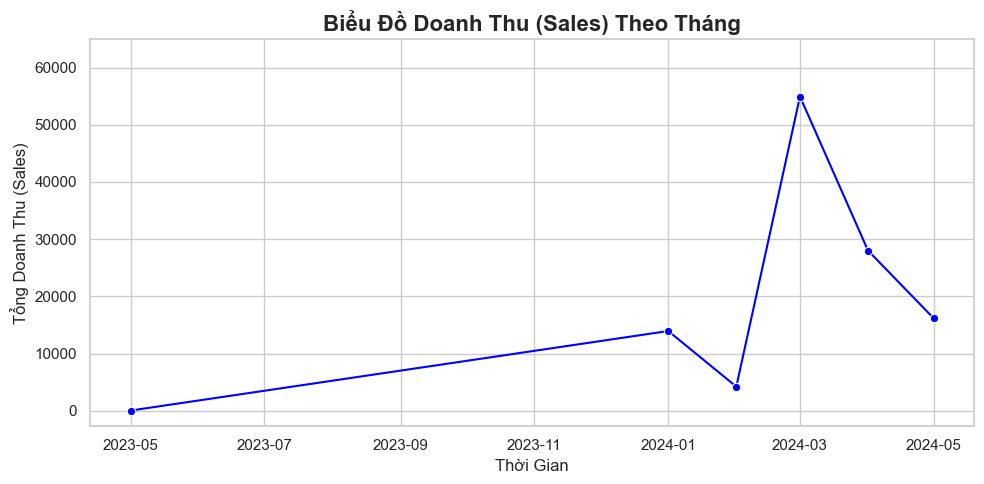

In [142]:
# Sales according to month/year
plt.figure(figsize=(10, 5)) 
sns.lineplot(data=monthly_data, x='YearMonth', y='Total_Sales', color='blue', marker='o')
plt.ylim(top = monthly_data['Total_Sales'].max() + 10000)
plt.title('Biểu Đồ Doanh Thu (Sales) Theo Tháng', fontsize=16, fontweight='bold')
plt.xlabel('Thời Gian', fontsize=12)
plt.ylabel('Tổng Doanh Thu (Sales)', fontsize=12)
plt.tight_layout()
plt.show()

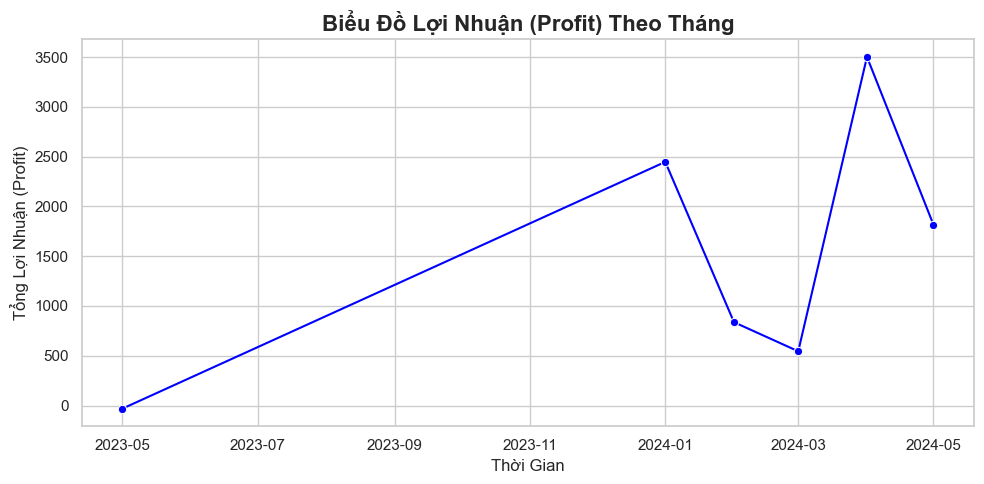

In [147]:
# Profit according to month/year
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_data, x='YearMonth', y='Total_Profit', color='blue', marker='o')
plt.title('Biểu Đồ Lợi Nhuận (Profit) Theo Tháng', fontsize=16, fontweight='bold')
plt.xlabel('Thời Gian', fontsize=12)
plt.ylabel('Tổng Lợi Nhuận (Profit)', fontsize=12)
plt.tight_layout()
plt.show()

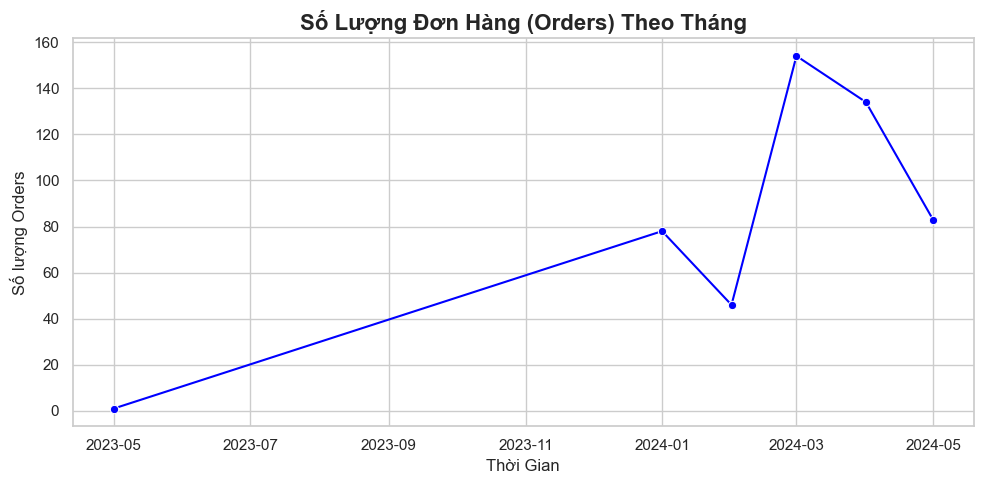

In [148]:
# the number of Orders according to month/year
plt.figure(figsize=(10, 5)) 
sns.lineplot(data=monthly_data, x='YearMonth', y='Total_Orders', color='blue', marker='o')
plt.title('Số Lượng Đơn Hàng (Orders) Theo Tháng', fontsize=16, fontweight='bold')
plt.xlabel('Thời Gian', fontsize=12)
plt.ylabel('Số lượng Orders', fontsize=12)
plt.tight_layout()
plt.show()

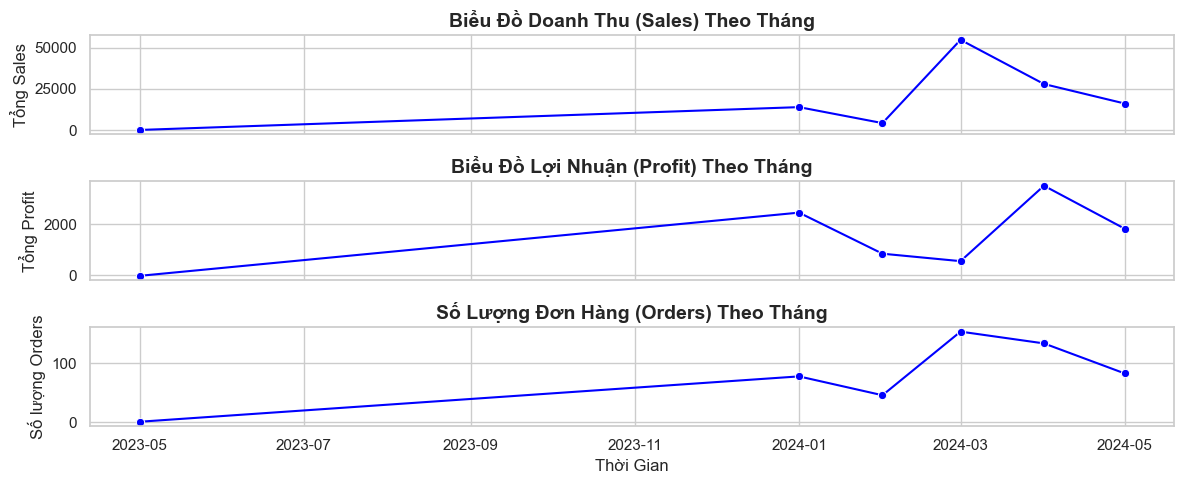

In [151]:
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

sns.lineplot(data=monthly_data, x='YearMonth', y='Total_Sales', ax=axes[0], color='blue', marker='o')
axes[0].set_title('Biểu Đồ Doanh Thu (Sales) Theo Tháng', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tổng Sales')

sns.lineplot(data=monthly_data, x='YearMonth', y='Total_Profit', ax=axes[1], color='blue', marker='o')
axes[1].set_title('Biểu Đồ Lợi Nhuận (Profit) Theo Tháng', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tổng Profit')

sns.lineplot(data=monthly_data, x='YearMonth', y='Total_Orders', ax=axes[2], color='blue', marker='o')
axes[2].set_title('Số Lượng Đơn Hàng (Orders) Theo Tháng', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Số lượng Orders')
axes[2].set_xlabel('Thời Gian')

plt.tight_layout()
plt.show()

# Doanh thu tăng hay giảm theo thời gian?

In [ ]:
# Theo tổng thể thì doanh thu đã tăng theo thời gian
# Nếu so sánh lúc bắt đầu tháng 05/2023 với các điểm của năm 2024, thì doanh thu đều cao hơn nhiều.
# Năm 2024, doanh thu có sự biến động mạnh tăng và đạt đỉnh vào khoảng tháng 03/2024, sau đó thì giảm dần về lại tháng 05/2024

# Có yếu tố mùa vụ không?

In [ ]:
# Chưa đủ dữ liệu để xác định điều này
# Do dữ liệu có khoảng không vào cuối năm 2023 nên không chắc chắn
# Việc doanh thu và đơn hàng cùng đạt đỉnh vào tháng 3 trong dữ liệu nhưng lợi nhuận lại sụt giảm so với tháng trước,
# có thể do có 1 sự kiện khuyến mãi hay tri ân khách hàng gì đó chưa chắc chắn là do mùa vụ

### Task 2 — Phân tích theo khu vực (Region/Province)
- Sales/Profit theo Region

- Top Province theo Sales

- So sánh Profit margin giữa các Region

Câu hỏi:

Khu vực nào bán nhiều nhưng lợi nhuận thấp?

# Prepare data

In [153]:
df_t2 = df_final.copy()

# Sales, Profit per Region
df_region = df_final.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# Profit_Margin = (Profit/Sales)*100
df_region['Profit_Margin_%'] = (df_region['Total_Profit'] / df_region['Total_Sales']) * 100

# Top provinces have most sales (Note: take 10)
df_province = df_final.groupby('Order_Province').agg(
    Total_Sales=('Sales', 'sum')
).reset_index().sort_values(by='Total_Sales', ascending=False).head(10)

# Plotting

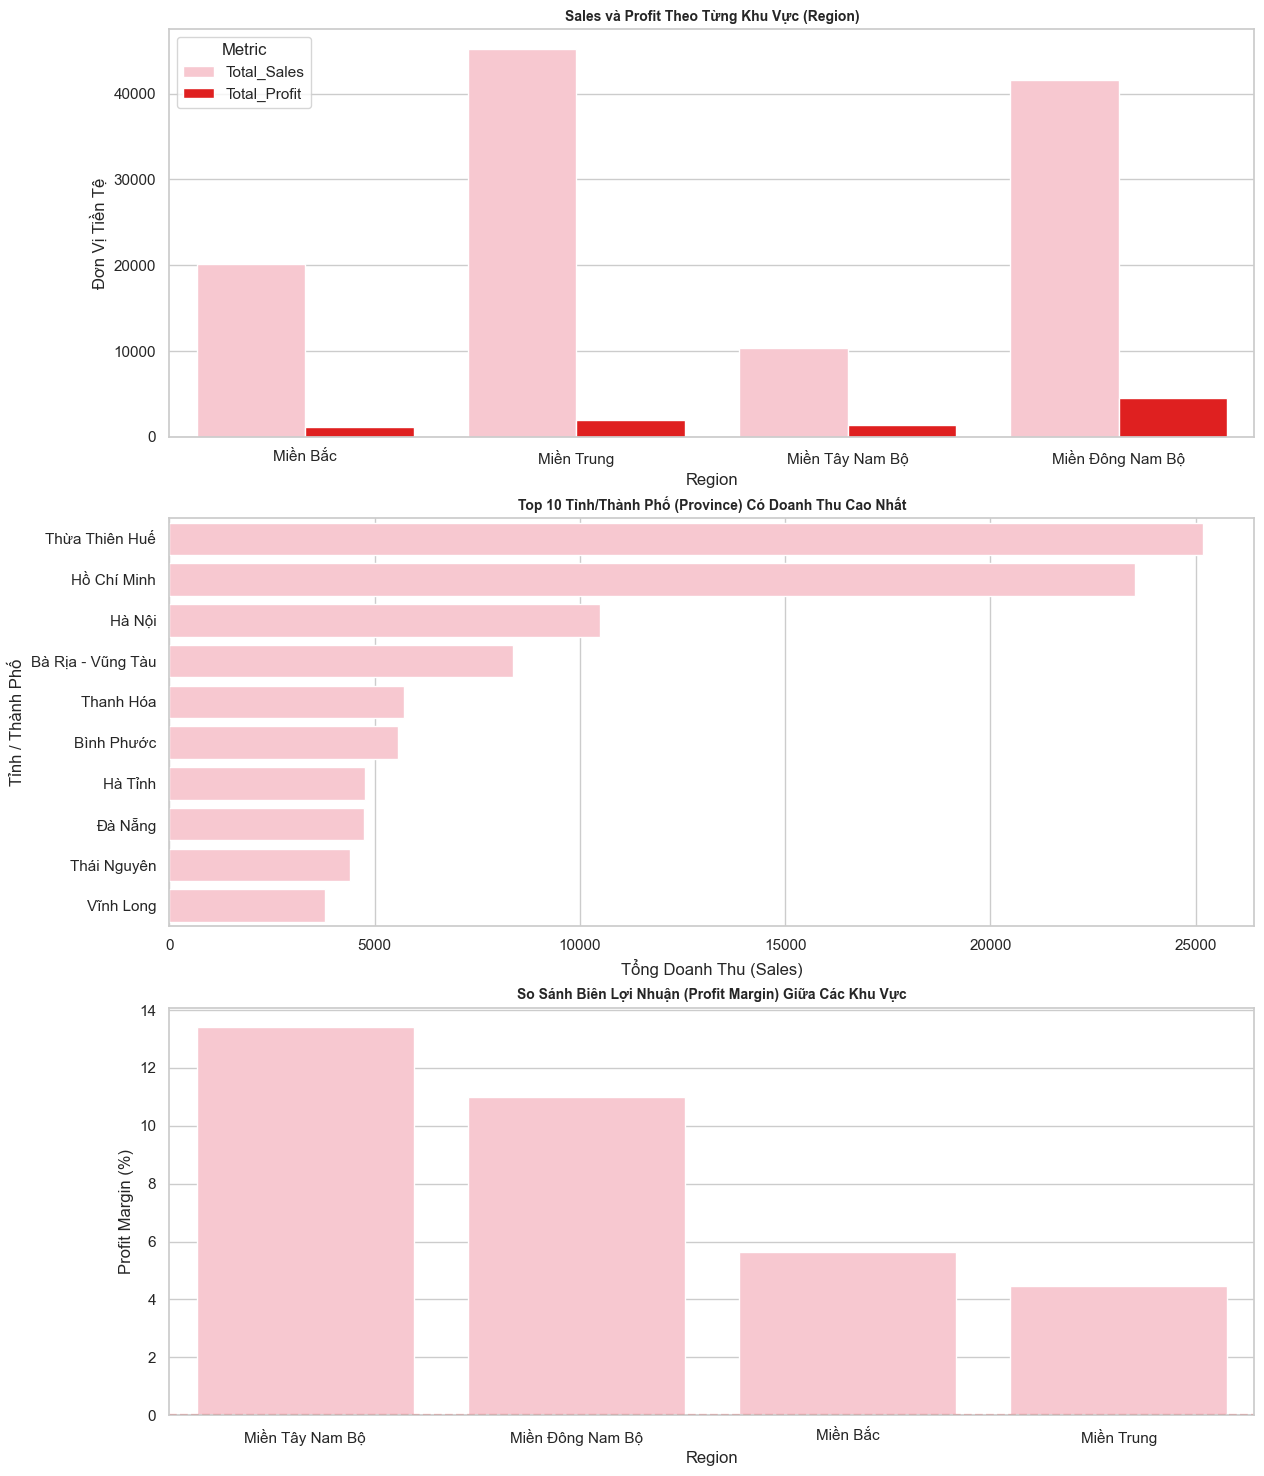

In [163]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Sales & Profit pẻ Region
df_region_melted = df_region.melt(id_vars='Region', value_vars=['Total_Sales', 'Total_Profit'], 
                                  var_name='Metric', value_name='Amount')
sns.barplot(data=df_region_melted, x='Region', y='Amount', hue='Metric', ax=axes[0], palette=['pink', 'red'])
axes[0].set_title('Sales và Profit Theo Từng Khu Vực (Region)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Đơn Vị Tiền Tệ')

# Top 10 Province per Sales
sns.barplot(data=df_province, x='Total_Sales', y='Order_Province', ax=axes[1], color='pink')
axes[1].set_title('Top 10 Tỉnh/Thành Phố (Province) Có Doanh Thu Cao Nhất', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Tổng Doanh Thu (Sales)')
axes[1].set_ylabel('Tỉnh / Thành Phố')

# Profit Margin pẻ Region 
df_region_sorted = df_region.sort_values(by='Profit_Margin_%', ascending=False)
sns.barplot(data=df_region_sorted, x='Region', y='Profit_Margin_%', ax=axes[2], color='pink')
axes[2].set_title('So Sánh Biên Lợi Nhuận (Profit Margin) Giữa Các Khu Vực', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Profit Margin (%)')
axes[2].axhline(0, color='red', linestyle='--')

Khu vực nào bán nhiều nhưng lợi nhuận thấp?

In [ ]:
# Miền Trung là khu vực bán nhiều nhưng có lợi nhuận thấp
# Biểu đồ 1: doanh thu miền Trung (1st) cao nhất nhưng lợi nhuận lại thấp hơn nhiều so với miền Đông Nam Bộ (2nd) 
# Biểu đồ 2: Thừa Thiên Huế chiếm top 1 về doanh thu cao hơn cả TP.HCM và HN -> Miền Trung chiếm doanh thu cao nhất
# Biểu đồ 3: Biên lợi nhuận của miền Trung lại thấp nhất 4 khu vực chỉ ~ 4%, trong khi Tây Nam Bộ và Đông Nam Bộ cao ~ x3 lần.
# -> Khu vực miền Trung tuy mang lại doanh thu cao nhất nhưng khả năng sinh lời thấp, có thể do chi phí vận chuyển vận chuyển cao hoặc có
# chi phi phát sinh hay do đây là thị trường mới nên chạy nhiều chương trình khuyến mãi

### Task 3 — Phân tích theo Customer
Vẽ:

Sales theo Industry_name
Top khách hàng theo doanh thu (Pareto 80/20)
Industry vs Region (heatmap)

Câu hỏi:

Nhóm khách hàng chính là ai?

In [164]:
from matplotlib.ticker import PercentFormatter

# Prepare data

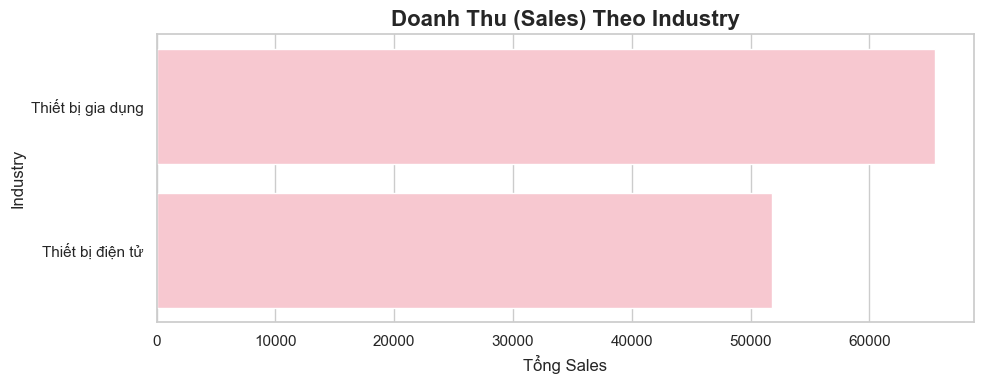

In [168]:
# Sales per Industry_name
plt.figure(figsize=(10, 4))
df_industry = df_final.groupby('Industry_name')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)

sns.barplot(data=df_industry, x='Sales', y='Industry_name', color='pink')
plt.title('Doanh Thu (Sales) Theo Industry', fontsize=16, fontweight='bold')
plt.xlabel('Tổng Sales')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

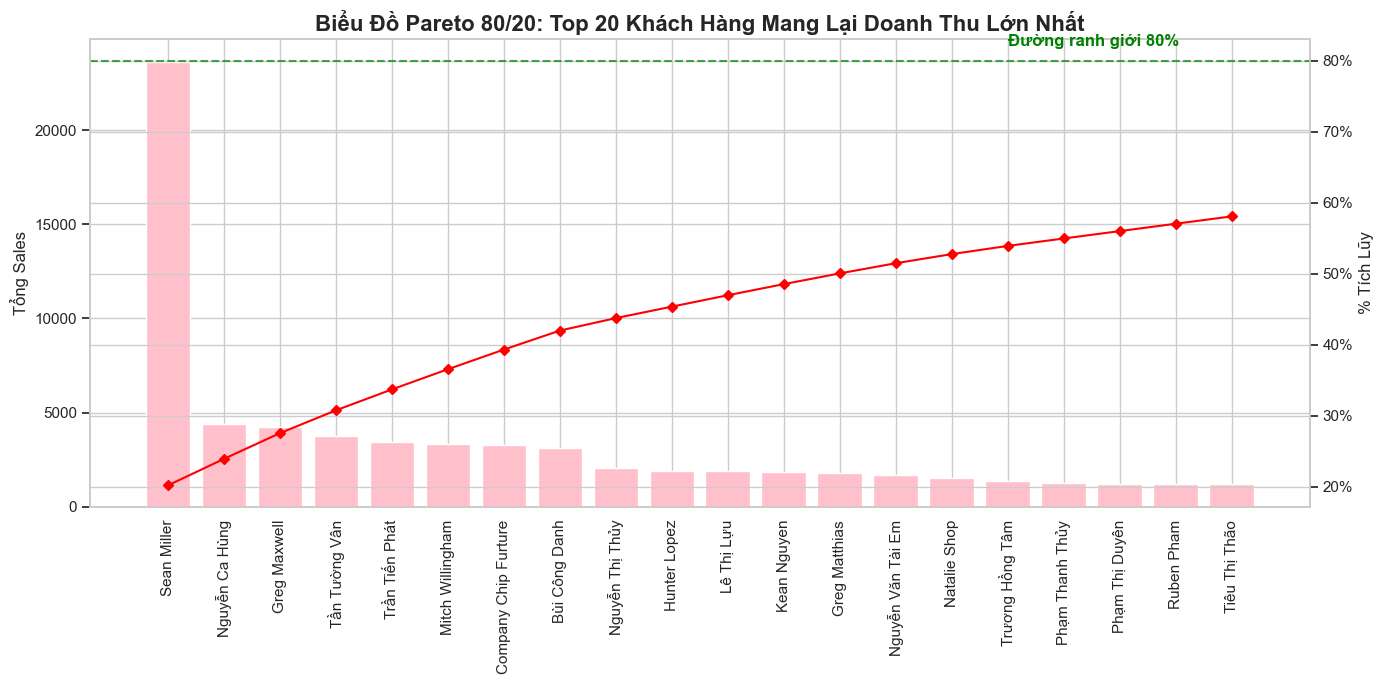

In [173]:
# Top customer according to sale Pareto (80/20) 

df_cust = df_final.groupby('Customer_Name')['Sales'].sum().reset_index()
df_cust = df_cust.sort_values(by='Sales', ascending=False)

# Cumulative Percentage
df_cust['Cumulative_Percent'] = df_cust['Sales'].cumsum() / df_cust['Sales'].sum() * 100

# Take top 20
df_pareto = df_cust.head(20)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Sales (Y main)
ax1.bar(df_pareto['Customer_Name'], df_pareto['Sales'], color='pink')
ax1.set_ylabel('Tổng Sales', fontsize=12)
ax1.set_xticks(range(len(df_pareto)))
ax1.set_xticklabels(df_pareto['Customer_Name'], rotation=90)

#  Cumulative Percentage (Y sub)
ax2 = ax1.twinx()
ax2.plot(df_pareto['Customer_Name'], df_pareto['Cumulative_Percent'], color='red', marker='D', ms=5)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('% Tích Lũy', fontsize=12)

# Pareto 80
ax2.axhline(80, color='green', linestyle='dashed', alpha=0.7)
ax2.text(len(df_pareto)-5, 82, 'Đường ranh giới 80%', color='green', fontweight='bold')

plt.title('Biểu Đồ Pareto 80/20: Top 20 Khách Hàng Mang Lại Doanh Thu Lớn Nhất', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

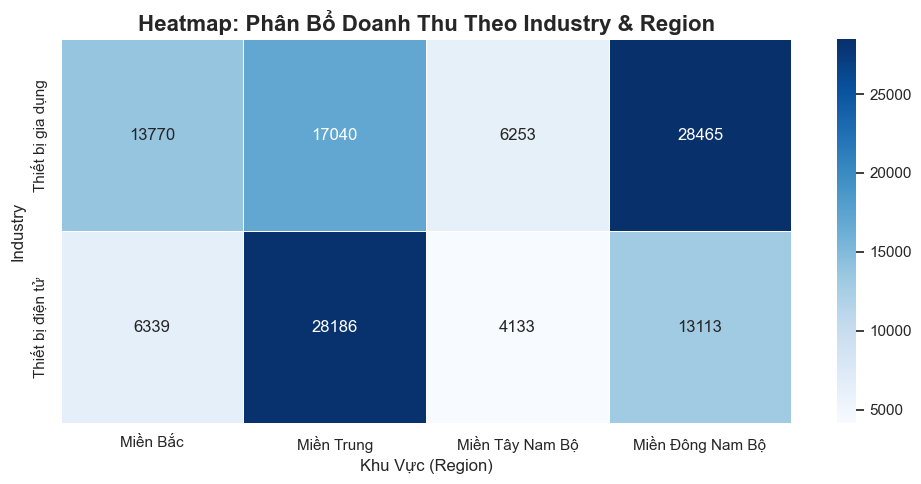

In [181]:
# Heatmap: Industry vs Region
heatmap_data = df_final.pivot_table(index='Industry_name', columns='Region', values='Sales', aggfunc='sum')

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues", linewidths=.5)
plt.title('Heatmap: Phân Bổ Doanh Thu Theo Industry & Region', fontsize=16, fontweight='bold')
plt.xlabel('Khu Vực (Region)')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

# Nhóm khách hàng chính là ai?

In [ ]:
# Nhóm các khách hàng chính là:
# các khách hàng mua thiết bị gia dùng ở Miền Đông Nam Bộ 28465
# các khách hàng mua thiết bị gia dùng ở Miền Trung 17040
# các khách hàng mua thiết bị điện tử ở Miền Trung 28186
# -> Nên tập trung phát triển nhiều hơn các sản phẩm trên ở 2 khu vực này hoặc tối ưu, quảng bá các chiến dịch

### Task 4 — Phân tích Returned_Reason

Vẽ:

- Tỷ lệ Returned theo Product / Region / Channel
- Phân bố Returned_Reason

Câu hỏi:

- Trả hàng tập trung ở đâu? Vì sao?

# Prepare data

In [182]:
df_final['Is_Returned'] = df_final['Returned_Reason'].notna().astype(int)

# Return rate
def calculate_return_rate(df, column):
    rate_df = df.groupby(column)['Is_Returned'].mean() * 100
    return rate_df.reset_index().sort_values(by='Is_Returned', ascending=False)

# Rate per Product_Category, Region, Channel
df_rate_product = calculate_return_rate(df_final, 'Product_Category')
df_rate_region = calculate_return_rate(df_final, 'Region')
df_rate_channel = calculate_return_rate(df_final, 'Channel')

# The number of returned reason
df_returned_only = df_final[df_final['Is_Returned'] == 1]
df_reason_dist = df_returned_only['Returned_Reason'].value_counts().reset_index()
df_reason_dist.columns = ['Returned_Reason', 'Count']

# Plotting

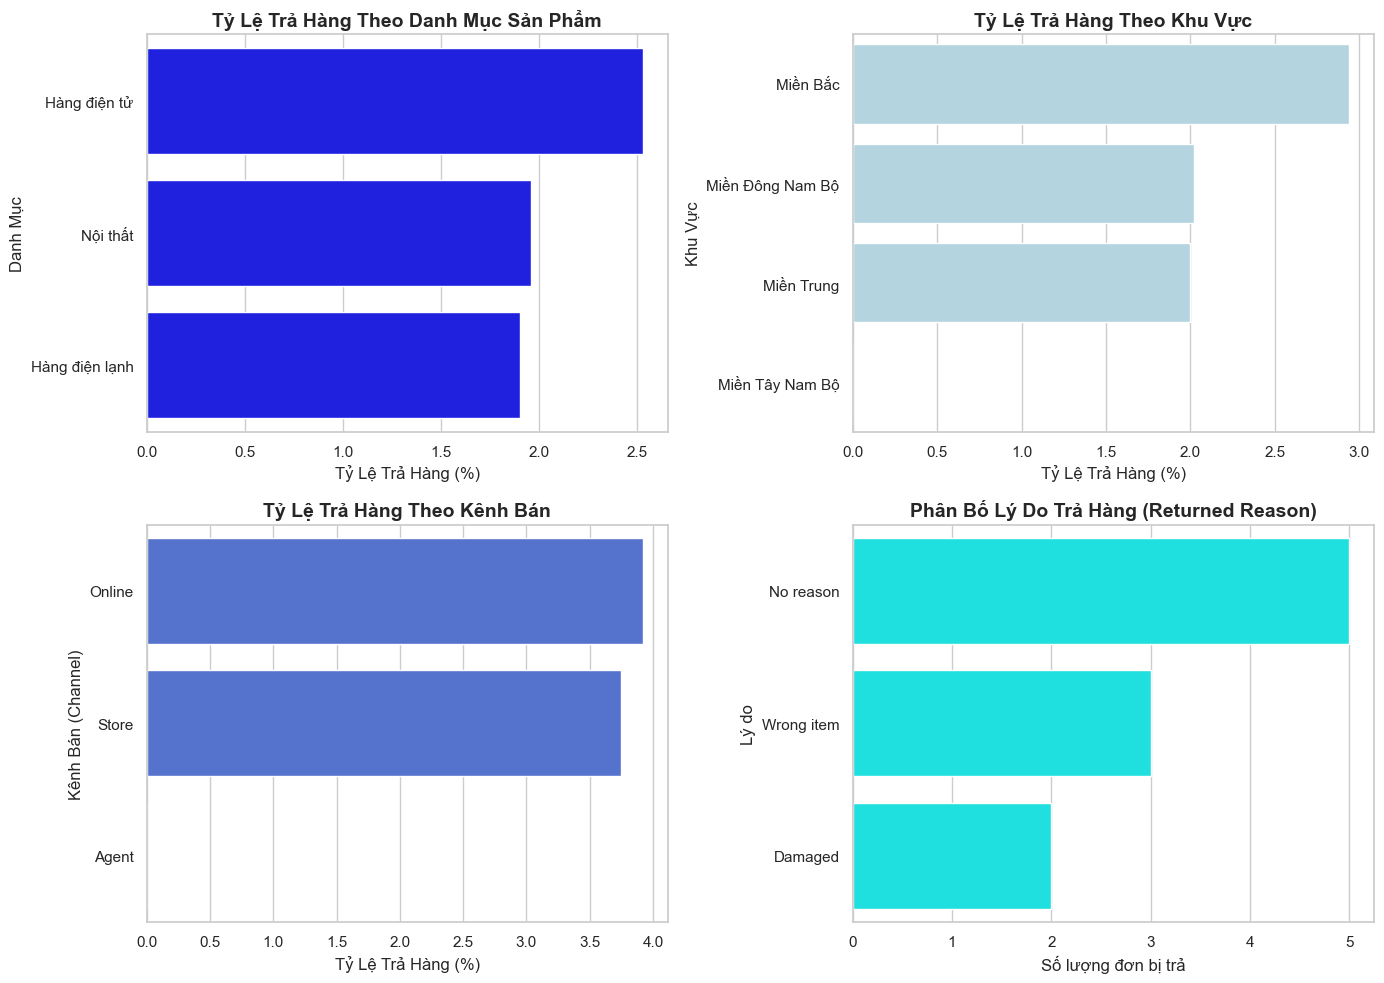

In [186]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Percentage of Return according to Product Category
sns.barplot(data=df_rate_product, x='Is_Returned', y='Product_Category', ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Tỷ Lệ Trả Hàng Theo Danh Mục Sản Phẩm', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Tỷ Lệ Trả Hàng (%)')
axes[0, 0].set_ylabel('Danh Mục')

# Percentage of Return according to Region 
sns.barplot(data=df_rate_region, x='Is_Returned', y='Region', ax=axes[0, 1], color='lightblue')
axes[0, 1].set_title('Tỷ Lệ Trả Hàng Theo Khu Vực', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Tỷ Lệ Trả Hàng (%)')
axes[0, 1].set_ylabel('Khu Vực')

# Percentage of Return according to Channel 
sns.barplot(data=df_rate_channel, x='Is_Returned', y='Channel', ax=axes[1, 0], color='royalblue')
axes[1, 0].set_title('Tỷ Lệ Trả Hàng Theo Kênh Bán', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Tỷ Lệ Trả Hàng (%)')
axes[1, 0].set_ylabel('Kênh Bán (Channel)')

# Returned Reason's allocation
sns.barplot(data=df_reason_dist, x='Count', y='Returned_Reason', ax=axes[1, 1], color='cyan')
axes[1, 1].set_title('Phân Bố Lý Do Trả Hàng (Returned Reason)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Số lượng đơn bị trả')
axes[1, 1].set_ylabel('Lý do')

plt.tight_layout()
plt.show()

# Trả hàng tập trung ở đâu? Vì sao?

In [ ]:
# Trả hàng tập trung ở loại hàng điện tử với 2.5%, cao hơn 0.5% so với hàng điện lạnh và nội thất
# Khu vực chủ yếu là miền bắc ~3%, thấp nhất là miền tây nam bộ với 0% 
# Kênh Online chiếm phần lớn tỷ lệ 4% cùng với store ~ theo sát
# Gồm 3 lí do chính: sai hàng, hư hỏng và không có lí do.
# Các loại hàng cồng kềnh như nội thất, hàng điện lạnh trong quá trình vận chuyển (mua qua online/store) dễ va chạm dẫn đến hư hại hoặc
# do lỗi của nhà sản xuất. Hàng điện tử tuy có thể nhỏ gọn nhưng dễ xảy ra lỗi hơn. Kênh bán online/store dễ xảy ra lỗi giao sai hàng hóa nếu người
# nhận không tự đến lấy hàng
# -> Cần rà soát lại sản phẩm trước khi đưa đến tay khách hàng
# Ngoài ra thủ tục trả hàng cần yêu cầu lí do để tránh khỏi tình trạng 'No reason'

In [188]:
monthly_data['Total_Orders'].sum()

np.int64(496)

In [ ]:
# Nhận xét: Tỷ lệ trả hàng là 10/496 đơn hàng do đó số lượng trả hàng của các khu vực chỉ chiếm 1 vài đơn.
# Nhưng do chủ yếu là hàng cồng kềnh hoặc đồ điện tử đắt tiền nên chi phí vận chuyển cao. 
# Việc trả hàng làm nhân đôi chi phí vận chuyển trong khi lợi nhuận là 0
# Đây có thể là lí do mà biên lợi nhuận ở miền Trung chỉ có 4% trong khi doanh thu đạt mức cao nhất ở 4 khu vực
# so với biên lợi nhuận 13% của miền tây nam bộ với tỷ lệ trả hàng là 0%
# -> Cần hạn chế hiện tượng trả hàng để tránh đội chi phí làm giảm biên lợi nhuận